In [49]:
import os
import pandas as pd
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
IMAGE_SIZE = (128, 128)
BATCH_SIZE = 32

all_real_dir = 'real_people'
celeb_real = 'celeba/img_align_celeba/img_align_celeba'
more_real_train = 'real_fake/real_vs_fake/real-vs-fake/train/real'
more_real_test = 'real_fake/real_vs_fake/real-vs-fake/test/real'
more_real_valid = 'real_fake/real_vs_fake/real-vs-fake/valid/real'
more_fake_train = 'real_fake/real_vs_fake/real-vs-fake/train/fake'
more_fake_test = 'real_fake/real_vs_fake/real-vs-fake/test/fake'
more_fake_valid = 'real_fake/real_vs_fake/real-vs-fake/valid/fake'
train_real_dir = 'Dataset/Train/Real'
train_fake_dir = 'Dataset/Train/Fake'
test_real_dir = 'Dataset/Test/Real'
validation_real_dir = 'Dataset/Validation/Real'
validation_fake_dir = 'Dataset/Validation/Fake'

test_fake_male_dir = 'ThisPersonDoesNotExist/male'
test_fake_female_dir = 'ThisPersonDoesNotExist/female'

def create_dataframe_from_directory(directory, label):
    image_files = [f for f in os.listdir(directory) if \
                   f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    image_paths = [os.path.join(directory, f) for f in image_files]
    df = pd.DataFrame({'path': image_paths, 'label': label})
    return df


In [51]:
all_real_df = pd.concat([
    create_dataframe_from_directory(train_real_dir, '1'),
    create_dataframe_from_directory(more_real_train, '1'),
    create_dataframe_from_directory(more_real_test, '1'),
    create_dataframe_from_directory(more_real_valid, '1'),
    create_dataframe_from_directory(validation_real_dir, '1'),
    create_dataframe_from_directory(test_real_dir, '1'),
    create_dataframe_from_directory(all_real_dir, '1'),
    create_dataframe_from_directory(celeb_real, '1')
], ignore_index=True)

all_fake_df = pd.concat([
    create_dataframe_from_directory(train_fake_dir, '0'),
    create_dataframe_from_directory(more_fake_train, '0'),
    create_dataframe_from_directory(more_fake_test, '0'),
    create_dataframe_from_directory(more_fake_valid, '0'),
    create_dataframe_from_directory(validation_fake_dir, '0'),
    create_dataframe_from_directory(test_fake_male_dir, '0'),
    create_dataframe_from_directory(test_fake_female_dir, '0')
], ignore_index=True)

all_df = pd.concat([all_real_df, all_fake_df], ignore_index=True)
all_df.drop_duplicates(subset='path', inplace=True)
all_df = all_df.sample(frac=1, random_state=42).reset_index(drop=True)

def verify_images(df):
    invalid = []
    for i, row in df.iterrows():
        path = row['path']
        try:
            with Image.open(path) as img:
                img.verify()
        except (IOError, SyntaxError):
            invalid.append((i))
    return invalid

def remove_invalid_images(df, invalid_images):
    index = [i for i in invalid_images]
    if index:
        df = df.drop(index).reset_index(drop=True)
        print(f"Removed {len(index)} invalid")
    else:
        print("No invalid")
    return df

invalid_train_images = verify_images(all_df)
all_df = remove_invalid_images(all_df, invalid_train_images)

Removed 1 invalid


In [52]:
train_df_temp, test_val_df_temp = train_test_split(all_df,
                                                   test_size=0.4,
                                                   random_state=42,
                                                   stratify=all_df['label'])
val_df_temp, test_df_temp = train_test_split(test_val_df_temp,
                                             test_size=0.5,
                                             random_state=42,
                                             stratify=\
                                                test_val_df_temp['label'])

train_df = train_df_temp.copy()
val_df = val_df_temp.copy()
test_df = test_df_temp.copy()

train_df['label'] = train_df['label'].astype(str)
val_df['label'] = val_df['label'].astype(str)
test_df['label'] = test_df['label'].astype(str)

print("Training DataFrame:")
print(train_df.head())

print("\nTraining DataFrame:")
print(train_df['label'].value_counts())

print("\nValidation DataFrame:")
print(val_df['label'].value_counts())

print("\nTest DataFrame:")
print(test_df['label'].value_counts())

print("\nLen Training DataFrame:", len(train_df))
print("Len Val DataFrame:", len(val_df))
print("Len Test DataFrame:", len(test_df))

Training DataFrame:
                                                     path label
293683  celeba/img_align_celeba/img_align_celeba/11543...     1
498034  celeba/img_align_celeba/img_align_celeba/07509...     1
297720             Dataset/Validation/Fake/fake_18025.jpg     0
297606                  Dataset/Train/Fake/fake_37528.jpg     0
380457  real_fake/real_vs_fake/real-vs-fake/train/fake...     0

Training DataFrame:
1    221705
0     97084
Name: label, dtype: int64

Validation DataFrame:
1    73902
0    32361
Name: label, dtype: int64

Test DataFrame:
1    73902
0    32361
Name: label, dtype: int64

Len Training DataFrame: 318789
Len Val DataFrame: 106263
Len Test DataFrame: 106263


In [53]:
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='path',
    y_col='label',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

validation_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='path',
    y_col='label',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='path',
    y_col='label',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 318789 validated image filenames belonging to 2 classes.
Found 106263 validated image filenames belonging to 2 classes.
Found 106263 validated image filenames belonging to 2 classes.


In [ ]:
model = models.Sequential()

model.add(layers.Conv2D(32, (3, 3), activation='relu',
                        input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=3,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE
)

test_loss, test_acc = model.evaluate(
    test_generator,
    steps=test_generator.samples // BATCH_SIZE
)
print('Test accuracy:', test_acc)

model.save('model_with_fake')

Epoch 1/3


2024-12-09 23:43:24.875224: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


9962/9962 [==============================] - ETA: 0s - loss: 0.2331 - accuracy: 0.8947

2024-12-09 23:55:07.540551: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


9962/9962 [==============================] - 913s 92ms/step - loss: 0.2331 - accuracy: 0.8947 - val_loss: 0.1794 - val_accuracy: 0.9253
Epoch 2/3
9962/9962 [==============================] - 944s 95ms/step - loss: 0.1342 - accuracy: 0.9459 - val_loss: 0.1246 - val_accuracy: 0.9508
Epoch 3/3
3320/3320 [==============================] - 216s 65ms/step - loss: 0.1221 - accuracy: 0.9519
Test accuracy: 0.9519295692443848


INFO:tensorflow:Assets written to: model_with_fake/assets


INFO:tensorflow:Assets written to: model_with_fake/assets


In [45]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_6 (Conv2D)           (None, 126, 126, 32)      896       
                                                                 
 max_pooling2d_6 (MaxPooling  (None, 63, 63, 32)       0         
 2D)                                                             
                                                                 
 conv2d_7 (Conv2D)           (None, 61, 61, 64)        18496     
                                                                 
 max_pooling2d_7 (MaxPooling  (None, 30, 30, 64)       0         
 2D)                                                             
                                                                 
 conv2d_8 (Conv2D)           (None, 28, 28, 128)       73856     
                                                                 
 max_pooling2d_8 (MaxPooling  (None, 14, 14, 128)     

3321/3321 [==============================] - 192s 58ms/step
F1-score: 0.9656688424746399
Precision: 0.9595217420346003
Recall: 0.9718952125788206
Accuracy: 0.9519399979296651


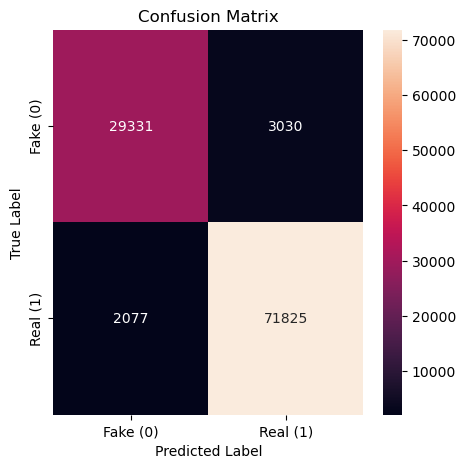

In [54]:
preds = model.predict(test_generator,
                      steps=test_generator.samples //\
                          test_generator.batch_size + 1, verbose=1)
y_pred = (preds > 0.5).astype(int).ravel()
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
accuracy = accuracy_score(y_true, y_pred)

print("F1-score:", f1)
print("Precision:", precision)
print("Recall:", recall)
print("Accuracy:", accuracy)

plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Fake (0)', 'Real (1)'],
            yticklabels=['Fake (0)', 'Real (1)'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()
